# Multi-DOF, multi-objective beamline optimization (blop) with raytracing (Shadow)
khchan@lbl.gov awojdyla@lbl.gov, Sep 2025

This script is based on blop 0.71

using `python 3.10.9` environment


In [144]:
from blop.utils import prepare_re_env

%run -i $prepare_re_env.__file__ --db-type=temp
# it would be great to have a proper bluesky database

<Figure size 640x480 with 0 Axes>

In [145]:
%matplotlib inline

import Shadow
import numpy as np
import matplotlib as mpl
from pathlib import Path
from matplotlib import pyplot as plt

In [146]:
# getting the beam size in for any beam shape
def beam_rms_size(x, y, I):
    """
    Compute the RMS (root mean square) beam size and centroid from ray data.

    This function calculates the second-moment beam size in both X and Y
    directions directly from a list of ray positions, using only rays
    that exist (I > 0).

    Parameters
    ----------
    x : 1D numpy.ndarray
        Array of X positions of rays (in meters, mm, etc.).
    y : 1D numpy.ndarray
        Array of Y positions of rays (same units as x).
    I : 1D numpy.ndarray
        Array of ray existence flags or intensities.
        Rays with I <= 0 are ignored.

    Returns
    -------
    total_rays : int
        Number of rays considered (I > 0).
    sigma_x : float
        RMS beam size in X direction.
    sigma_y : float
        RMS beam size in Y direction.
    x_centroid : float
        Centroid position in X.
    y_centroid : float
        Centroid position in Y.

    Notes
    -----
    - The RMS size is defined as:
        sigma_x = sqrt(mean((x - x_centroid)^2))
        sigma_y = sqrt(mean((y - y_centroid)^2))
      over all valid rays.
    - For a Gaussian beam, the FWHM can be obtained as:
        FWHM = 2.35482 * sigma
    - This method is robust and fast, and does not assume a Gaussian profile.

    Examples
    --------
    >>> total, sigma_x, sigma_y, cx, cy = beam_rms_size_from_rays(x, y, I)
    >>> fwhm_x = 2.35482 * sigma_x
    >>> fwhm_y = 2.35482 * sigma_y
    """
    # Keep only rays with I > 0
    mask = I > 0
    #mask = np.all((np.abs(x) > 1e-8, np.abs(x) < 2e-3, np.abs(y) > 1e-8, np.abs(y) < 2e-3), 0)
    x_valid = x[mask]
    y_valid = y[mask]
    I = I[mask]

    # intensity
    intensity = np.sum(I)
    total_rays = len(x_valid)


    # Centroid positions
    x_centroid = np.mean(x_valid)
    y_centroid = np.mean(y_valid)

    # RMS sizes
    sigma_x = np.sqrt(np.mean((x_valid - x_centroid) ** 2))
    sigma_y = np.sqrt(np.mean((y_valid - y_centroid) ** 2))
    # to avoid division by 0
    if total_rays < 50 or sigma_x<1e-10 or sigma_y<1e-10:
        return 1e-5, 100, 100, 100, 100

    return intensity, sigma_x, sigma_y, x_centroid, y_centroid

Define the beamline5.3.1 by shadow

In [147]:
"""
# mirror pitch (DOF1)
oe1.X_ROT = 1e-09
# mirror bend (DOF2)
oe1.R_MAJ = 2400.0

# Mono angle – same variable  (DOF3)
oe2.T_INCIDENCE = 75.6898061088
oe2.T_REFLECTION = 75.6898061088
oe3.T_INCIDENCE = 75.6898061088
oe3.T_REFLECTION = 75.6898061088

# slit position (DOF4)
oe4.CX_SLIT = numpy.array([1e-09, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
oe4.CZ_SLIT = numpy.array([1e-09, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

# write (1) or not (0) SHADOW files start.xx end.xx star.xx

iwrite = 0
"""

def beamline_531(X_ROT = 0, R_MAJ = 2400, MONO_ANGLE = 75.6898061088, SLIT_CX = 1e-9, SLIT_CZ = 1e-9, SLIT_RX = 1e-3, SLIT_RZ = 5e-4):
    # Define the object in beamline
    beam = Shadow.Beam()
    oe0 = Shadow.Source()
    oe1 = Shadow.OE()
    oe2 = Shadow.OE()
    oe3 = Shadow.OE()
    oe4 = Shadow.OE()
    oe5 = Shadow.OE()
    oe6 = Shadow.OE()
    
    
    oe0.FDISTR = 3
    oe0.F_PHOT = 0
    oe0.F_POLAR = 0
    oe0.HDIV1 = 0.0
    oe0.HDIV2 = 0.0
    oe0.IDO_VX = 0
    oe0.IDO_VZ = 0
    oe0.IDO_X_S = 0
    oe0.IDO_Y_S = 0
    oe0.IDO_Z_S = 0
    oe0.ISTAR1 = 0
    oe0.NPOINT = 10000
    oe0.PH1 = 8000.0
    oe0.SIGDIZ = 1e-05
    oe0.SIGMAX = 0.0003
    oe0.SIGMAZ = 0.0001
    oe0.VDIV1 = 0.0
    oe0.VDIV2 = 0.0
    
    
    
    oe1.ALPHA = 180.0
    oe1.DUMMY = 100.0
    oe1.FMIRR = 3
    oe1.FWRITE = 1
    oe1.F_EXT = 1
    oe1.F_MOVE = 1
    oe1.R_MAJ = R_MAJ
    oe1.R_MIN = 0.06
    oe1.T_IMAGE = 0.0
    oe1.T_INCIDENCE = 89.7135211024
    oe1.T_REFLECTION = 89.7135211024
    oe1.T_SOURCE = 12.0
    oe1.X_ROT = X_ROT
    oe1.Y_ROT = 0
    
    
    oe2.DUMMY = 100.0
    oe2.FILE_REFL = b'./bragg.dat'
    oe2.FWRITE = 1
    oe2.F_CENTRAL = 1
    oe2.F_CRYSTAL = 1
    oe2.PHOT_CENT = 8000.0
    oe2.R_LAMBDA = 5000.0
    oe2.T_IMAGE = 0.0
    oe2.T_INCIDENCE = MONO_ANGLE # 75.6898061088
    oe2.T_REFLECTION = MONO_ANGLE #75.6898061088
    
    
    
    oe3.ALPHA = 180.0
    oe3.DUMMY = 100.0
    oe3.FILE_REFL = b'./bragg.dat'
    oe3.FWRITE = 1
    oe3.F_CENTRAL = 1
    oe3.F_CRYSTAL = 1
    oe3.PHOT_CENT = 8000.0
    oe3.R_LAMBDA = 5000.0
    oe3.T_IMAGE = 0.0
    oe3.T_INCIDENCE = MONO_ANGLE # 75.6898061088
    oe3.T_REFLECTION = MONO_ANGLE # 75.6898061088
    oe3.T_SOURCE = 0.2

    
    oe4.CX_SLIT = np.array([SLIT_CX, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    oe4.CZ_SLIT = np.array([SLIT_CZ, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    oe4.DUMMY = 100.0
    oe4.FWRITE = 3
    oe4.F_REFRAC = 2
    oe4.F_SCREEN = 1
    oe4.I_SLIT = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    oe4.N_SCREEN = 1
    oe4.RX_SLIT = np.array([SLIT_RX, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    oe4.RZ_SLIT = np.array([SLIT_RZ, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
    oe4.T_IMAGE = 0.0
    oe4.T_INCIDENCE = 0.0
    oe4.T_REFLECTION = 180.0
    oe4.T_SOURCE = 0.8
    
    
    
    oe5.DUMMY = 100.0
    oe5.FWRITE = 3
    oe5.F_REFRAC = 2
    oe5.F_SCREEN = 1
    oe5.N_SCREEN = 1
    oe5.T_IMAGE = 0.0
    oe5.T_INCIDENCE = 0.0
    oe5.T_REFLECTION = 180.0
    oe5.T_SOURCE = 1.0

    beam.genSource(oe0)
    beam.traceOE(oe1,1)
    beam.traceOE(oe2,2)
    beam.traceOE(oe3,3)
    beam.traceOE(oe4,4)
    beam.traceOE(oe5,5)

    X = beam.getshcol(1)
    Y = beam.getshcol(3)
    # normalize the intensity by the number of rays
    I = beam.getshcol(10)/oe0.NPOINT
    # intensity = (beam.getshcol(7)+beam.getshcol(16))**2 + (beam.getshcol(8)+beam.getshcol(17))**2 + (beam.getshcol(9)++beam.getshcol(18))**2
    mask = I>0
    print(np.sum(mask))
    print(np.sum(intensity[mask]))
    X = X[mask]
    Y = Y[mask]
    I = I[mask]
    return X,Y,I

[6.20587006e-09 3.90661213e-08 1.18937183e-06 ... 8.00771439e-07
 7.82437492e-04 1.71006075e-05]
249
63.246043968949806
0.024900000000000005


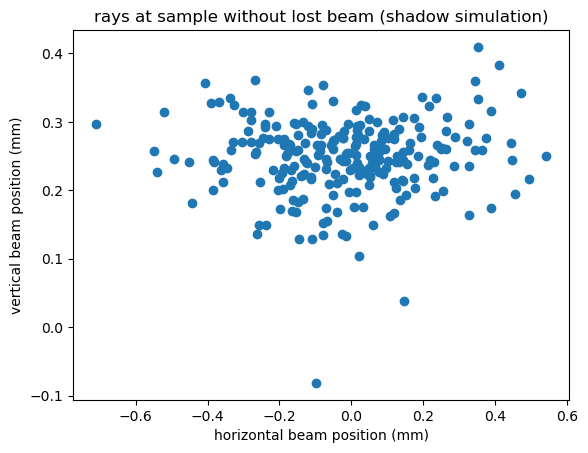

In [148]:
(X,Y,I) = beamline_531(0.001)
# removing the lost beam
X = X[I>0]
Y = Y[I>0]
I = I[I>0]
# intensity
print(np.sum(I))
plt.scatter(1e3*X,1e3*Y)
plt.title('rays at sample without lost beam (shadow simulation)')
plt.xlabel('horizontal beam position (mm)')
plt.ylabel('vertical beam position (mm)')
plt.show()

In [6]:
(total_intensity, sigma_x, sigma_y, x_centroid, y_centroid) = beam_rms_size(X, Y, I)

In [7]:
total_intensity, sigma_x, sigma_y, x_centroid, y_centroid

(0.9923000000000003,
 0.00031147595989256373,
 0.0002314750165646956,
 7.684524071215652e-06,
 -0.00045957180715088306)

In [8]:
from blop import Objective
# power density
objectives = [Objective(name="power_density", description="power_density", target="max"),
              #Objective(name="beamsize", description="beamsize", target="min"), 
             #Objective(name="beam_intensity", description="beam_intensity", target="max"),
             #Objective(name="slit_size", description="slit_size", target="min"),
             ]

In [42]:
# from https://nsls-ii.github.io/blop/tutorials/introduction.html
# def digestion(df):
#     for index, entry in df.iterrows():
#         df.loc[index, "himmelblau"] = functions.himmelblau(entry.x1, entry.x2)

#     return df

#new: 
# unit log / normalize
# x_rot = 0.00045  r_maj = 2271.625488mono_angle = 75.766228
def digestion(df):
    for index, entry in df.iterrows():
        # remove
        X, Y, I = beamline_531(entry.x_rot, entry.r_maj, entry.mono_angle, entry.slit_cx, entry.slit_cz, SLIT_RX = entry.slit_rx, SLIT_RZ = entry.slit_rz)#, SLIT_RX = entry.slit_rx, SLIT_RZ = entry.slit_rz)
        (total_intensity, sigma_x, sigma_y, x_centroid, y_centroid) = beam_rms_size(X, Y, I) 
        # power density hist1, xedges, yedges = np.histogram2d(X*1e3, Y*1e3, bins=1, range=[[x_centroid-0.05, x_centroid+0.05], [y_centroid-0.05, y_centroid+0.05]])
        df.loc[index, "power_density"] = total_intensity/(sigma_x**2 + sigma_y**2)
        df.loc[index, "beamsize"] = np.sqrt(sigma_x**2 + sigma_y**2)
        df.loc[index, "beam_intensity"] = total_intensity
        #df.loc[index, "slit_size"] = np.sqrt(entry.slit_rx**2 + entry.slit_rz**2)
        print( total_intensity/np.sqrt(sigma_x**2 + sigma_y**2))

    return df

In [149]:
from blop import DOF
"""
dofs = [
    DOF(name="x_rot", search_domain=(-0.05, 0.05)),
    DOF(name="r_maj", search_domain=(2000, 2800)),
    DOF(name="slit_cx", search_domain=(-0.05, 0.05)),
    DOF(name="slit_cz", search_domain=(-0.05, 0.05)),
    DOF(name="slit_rx", search_domain=(0.001, 0.005)),
    DOF(name="slit_rz", search_domain=(0.001, 0.005)),
]
"""
# unit
dofs = [
    DOF(name="x_rot", search_domain=(-0.001, 0.001)),
    DOF(name="r_maj", search_domain=(2200, 5000)),
    DOF(name="mono_angle", search_domain=(70, 80)),
    DOF(name="slit_rx", search_domain=(0.0001, 0.01)),
    DOF(name="slit_rz", search_domain=(0.0001, 0.01)),
    DOF(name="slit_cx", search_domain=(-0.005, 0.005)),
    DOF(name="slit_cz", search_domain=(-0.005, 0.005)),
    #DOF(name="slit_rx", search_domain=(0.0001, 0.01)),
    #DOF(name="slit_rz", search_domain=(0.0001, 0.005)),
]

In [150]:
from blop import Agent

agent = Agent(
    dofs=dofs,
    objectives=objectives,
    digestion=digestion,
    db=db,
    
)

2025-09-25 21:45:22.550 INFO: Executing plan <generator object Agent.learn at 0x000002B5EB76ED50>
2025-09-25 21:45:22.594 INFO: Change state on <bluesky.run_engine.RunEngine object at 0x000002B5DACF4550> from 'idle' -> 'running'




Transient Scan ID: 1     Time: 2025-09-25 21:45:30
Persistent Unique Scan ID: '9f73c30f-394f-4f58-b526-d936947acb75'
New stream: 'primary'
+-----------+------------+------------+------------+------------+------------+------------+------------+------------+
|   seq_num |       time |      x_rot |      r_maj | mono_angle |    slit_rx |    slit_rz |    slit_cx |    slit_cz |
+-----------+------------+------------+------------+------------+------------+------------+------------+------------+
|         1 | 21:45:30.5 |      0.001 |   2266.291 |     77.128 |      0.004 |      0.005 |     -0.000 |     -0.001 |
|         2 | 21:45:30.6 |      0.001 |   2596.808 |     75.662 |      0.005 |      0.007 |     -0.002 |      0.001 |
|         3 | 21:45:30.7 |     -0.000 |   3600.450 |     74.062 |      0.005 |      0.005 |     -0.001 |      0.001 |
|         4 | 21:45:30.7 |     -0.000 |   3974.716 |     72.557 |      0.006 |      0.007 |     -0.000 |     -0.002 |
|         5 | 21:45:30.8 |     -0

C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


7.071067811865476e-08
[8.20383918e-01 7.75949382e-02 5.75808365e-03 ... 2.59660162e-07
 5.44592969e-01 1.00770243e-01]
40
7.901757696321599
7.071067811865476e-08
[8.78340059e-01 9.73476017e-05 4.11578978e-05 ... 8.81627706e-01
 2.15022380e-03 6.22088910e-01]
5381
2322.5334530303276
1468.240067324273
[1.51384404e-03 8.57940736e-01 1.39514989e-05 ... 5.25136822e-01
 3.38638959e-03 8.78246745e-01]
350
35.48986661318894
53.1789784194361
[8.80727548e-01 8.67476431e-01 1.34269961e-05 ... 4.17107496e-04
 2.47940888e-01 7.18599884e-01]
1398
378.45659756490426
265.0598862248712
[6.50718321e-02 4.46099571e-05 1.90585706e-01 ... 8.44547130e-01
 2.98565099e-03 6.31687308e-02]
2278
487.4089522134322
234.03518230651656
[0.88022218 0.83795158 0.79834844 ... 0.00192205 0.86315458 0.00987371]
1
0.823142746690796
7.071067811865476e-08
[2.01187274e-04 4.20289768e-06 5.85219444e-03 ... 5.94726302e-03
 8.63051517e-01 3.39866655e-04]
0
0.0


C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


...

C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


7.071067811865476e-08
[9.27371259e-06 1.94407393e-04 8.31001321e-05 ... 5.53278463e-01
 3.15471813e-02 4.58911035e-06]
0
0.0


C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


7.071067811865476e-08
[5.27104816e-01 8.70327066e-01 7.80157870e-04 ... 3.23349882e-04
 8.40499175e-05 2.33106938e-04]
9915
2658.0648390430115
608.8346937237221


C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc

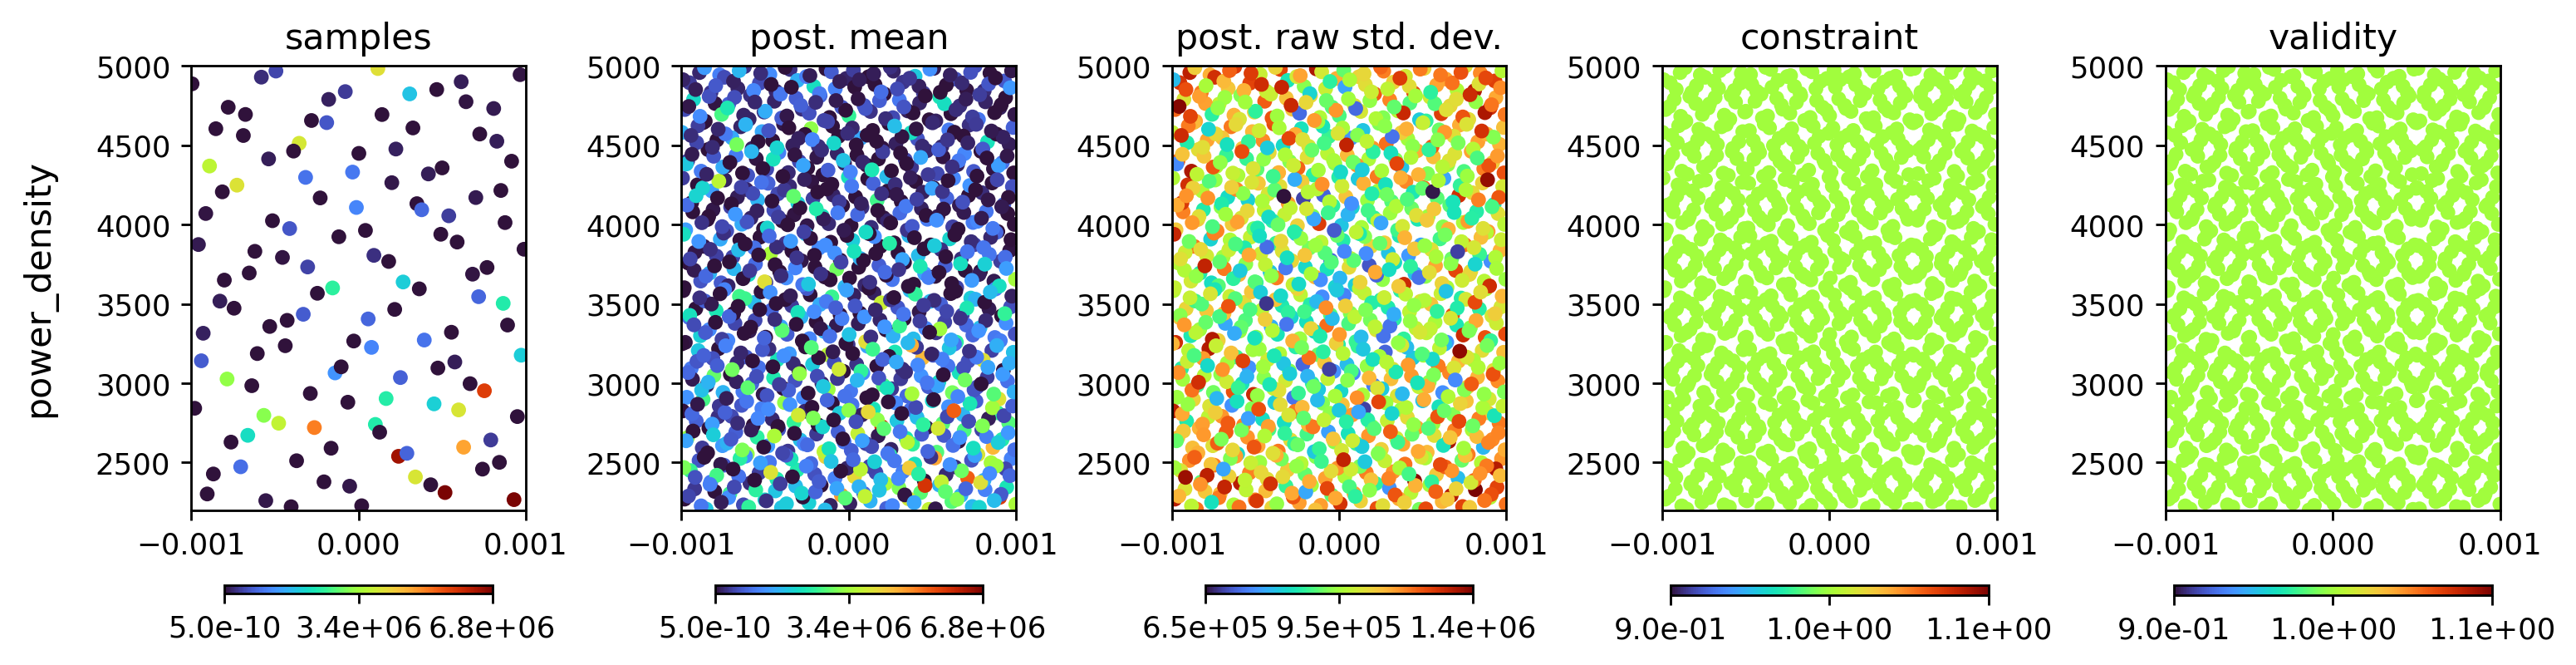

In [151]:
RE(agent.learn("quasi-random", n=128))
agent.plot_objectives()

In [152]:
agent.all_acqfs

,identifier,type,multitask_only,description
name,,,,
expected_improvement,ei,analytic,False,"The expected value of max(f(x) - \nu, 0), wher..."
expected_mean,em,analytic,False,The expected value at each input.
noisy_expected_hypervolume_improvement,nehvi,analytic,True,It's like a big box. How big is the box?
probability_of_improvement,pi,analytic,False,The probability that this input improves on th...
upper_confidence_bound,ucb,analytic,False,"The expected value, plus some multiple of the ..."
lower_bound_max_value_entropy,lbmve,monte_carlo,False,"Max entropy search, basically"
monte_carlo_expected_improvement,qei,monte_carlo,False,"The expected value of max(f(x) - \nu, 0), wher..."
monte_carlo_expected_mean,qem,monte_carlo,False,The expected value at each input.
monte_carlo_noisy_expected_hypervolume_improvement,qnehvi,monte_carlo,True,It's like a big box. How big is the box?


C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:312.)
  D[self.diag_matrix_indices] = self.lengthscales.ravel() ** -1


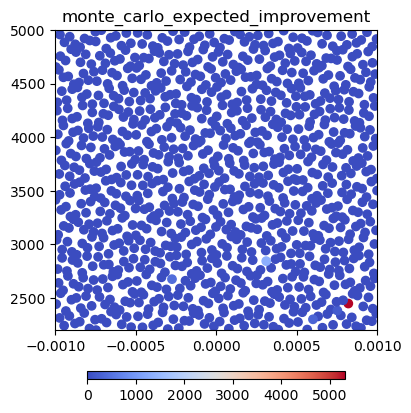

In [153]:
agent.plot_acquisition(acqf="qei")

In [49]:
RE(agent.learn("qei", n=5, iterations=16))

2025-09-18 15:09:45.712 INFO: Executing plan <generator object Agent.learn at 0x000002B5E2D5A180>
2025-09-18 15:09:45.716 INFO: Change state on <bluesky.run_engine.RunEngine object at 0x000002B5DACF47C0> from 'idle' -> 'running'




Transient Scan ID: 68     Time: 2025-09-18 15:10:08
Persistent Unique Scan ID: '9bee1359-9d98-402c-86e8-f67da2940d77'
New stream: 'primary'
+-----------+------------+------------+------------+------------+------------+------------+------------+------------+
|   seq_num |       time |      x_rot |      r_maj | mono_angle |    slit_rx |    slit_rz |    slit_cx |    slit_cz |
+-----------+------------+------------+------------+------------+------------+------------+------------+------------+
|         1 | 15:10:08.1 |     -0.001 |   2286.144 |     70.000 |      0.010 |      0.008 |      0.000 |      0.002 |
|         2 | 15:10:08.1 |     -0.001 |   2214.636 |     80.000 |      0.009 |      0.004 |      0.002 |     -0.000 |
|         3 | 15:10:08.1 |     -0.000 |   2284.733 |     72.520 |      0.007 |      0.002 |      0.002 |      0.000 |
|         4 | 15:10:08.2 |      0.000 |   2290.210 |     71.662 |      0.009 |      0.001 |      0.002 |     -0.000 |
|         5 | 15:10:08.2 |      

C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc



Transient Scan ID: 69     Time: 2025-09-18 15:10:41
Persistent Unique Scan ID: '1333acc9-71e1-4aa7-a166-d932383c85d8'
New stream: 'primary'
+-----------+------------+------------+------------+------------+------------+------------+------------+------------+
|   seq_num |       time |      x_rot |      r_maj | mono_angle |    slit_rx |    slit_rz |    slit_cx |    slit_cz |
+-----------+------------+------------+------------+------------+------------+------------+------------+------------+
|         1 | 15:10:41.9 |      0.000 |   2295.640 |     70.685 |      0.009 |      0.002 |      0.003 |     -0.000 |
|         2 | 15:10:41.9 |     -0.001 |   2309.704 |     76.148 |      0.010 |      0.007 |     -0.002 |      0.002 |
|         3 | 15:10:41.9 |     -0.001 |   2246.071 |     70.000 |      0.010 |      0.008 |     -0.002 |      0.002 |
|         4 | 15:10:42.0 |     -0.001 |   2243.417 |     80.000 |      0.010 |      0.006 |      0.002 |      0.001 |
|         5 | 15:10:42.0 |     -

C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc

...



Transient Scan ID: 82     Time: 2025-09-18 15:19:03
Persistent Unique Scan ID: '3c4cddf5-99cf-4eff-8ec3-dbce95e7f10b'
New stream: 'primary'
+-----------+------------+------------+------------+------------+------------+------------+------------+------------+
|   seq_num |       time |      x_rot |      r_maj | mono_angle |    slit_rx |    slit_rz |    slit_cx |    slit_cz |
+-----------+------------+------------+------------+------------+------------+------------+------------+------------+
|         1 | 15:19:03.2 |     -0.001 |   2278.973 |     77.747 |      0.009 |      0.003 |      0.001 |     -0.000 |
|         2 | 15:19:03.3 |     -0.000 |   2200.000 |     70.000 |      0.010 |      0.009 |     -0.002 |      0.003 |
|         3 | 15:19:03.3 |      0.000 |   2200.000 |     70.000 |      0.010 |      0.010 |     -0.001 |      0.003 |
|         4 | 15:19:03.3 |      0.000 |   2248.572 |     70.000 |      0.008 |      0.010 |     -0.001 |      0.003 |
|         5 | 15:19:03.4 |     -

C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc



Transient Scan ID: 83     Time: 2025-09-18 15:19:49
Persistent Unique Scan ID: '1d70a6ec-cff0-4c83-9685-56d2588bb5b4'
New stream: 'primary'
+-----------+------------+------------+------------+------------+------------+------------+------------+------------+
|   seq_num |       time |      x_rot |      r_maj | mono_angle |    slit_rx |    slit_rz |    slit_cx |    slit_cz |
+-----------+------------+------------+------------+------------+------------+------------+------------+------------+
|         1 | 15:19:49.1 |     -0.000 |   2200.000 |     70.000 |      0.010 |      0.008 |      0.004 |      0.004 |
|         2 | 15:19:49.1 |     -0.001 |   2237.272 |     70.473 |      0.010 |      0.006 |      0.004 |      0.003 |
|         3 | 15:19:49.1 |     -0.001 |   2200.000 |     70.000 |      0.008 |      0.008 |      0.003 |      0.001 |
|         4 | 15:19:49.2 |     -0.001 |   2200.000 |     80.000 |      0.010 |      0.003 |      0.001 |      0.000 |
|         5 | 15:19:49.2 |      

C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc

('9bee1359-9d98-402c-86e8-f67da2940d77',
 '1333acc9-71e1-4aa7-a166-d932383c85d8',
 '7946bc2b-f3f5-41c3-885d-9ccdaedf9ba2',
 '3baf0033-1925-4e11-bc49-146483366f40',
 '106f4086-9313-483f-87b8-6b839254a6c4',
 '764f8152-c0d3-4c6a-8900-8fb088d0c01c',
 'ab2742ff-03d2-4a6a-ae04-48bc63dc33be',
 '4c58921c-543e-47e4-ba86-0c509e49229f',
 '1e651936-c830-415c-ace9-c0cb16779933',
 '594f7357-005c-4c60-b737-7bde45d14cae',
 '226fd683-2c25-4dca-adf7-5b3f2304fdf6',
 'cbdc0e09-180c-4c89-baa2-8ce7a6d90c62',
 '7a4c65e7-ec14-4abe-895b-914f99636ea1',
 'a45d8762-5523-44bd-9701-5dc4a457c429',
 '3c4cddf5-99cf-4eff-8ec3-dbce95e7f10b',
 '1d70a6ec-cff0-4c83-9685-56d2588bb5b4')

C:\Users\tkp20\anaconda3\envs\blop\lib\site-packages\blop\bayesian\kernels.py:157: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:312.)
  D[self.diag_matrix_indices] = self.lengthscales.ravel() ** -1


x_rot                                     0.000008
r_maj                                  2306.036621
mono_angle                               72.306389
slit_rx                                   0.007507
slit_rz                                   0.001741
slit_cx                                   0.001916
slit_cz                                   0.000017
power_density                       8995616.955924
time                 2025-09-18 22:03:24.582336187
beamsize                                  0.000322
beam_intensity                              0.9337
acqf              monte_carlo_expected_improvement
Name: 191, dtype: object


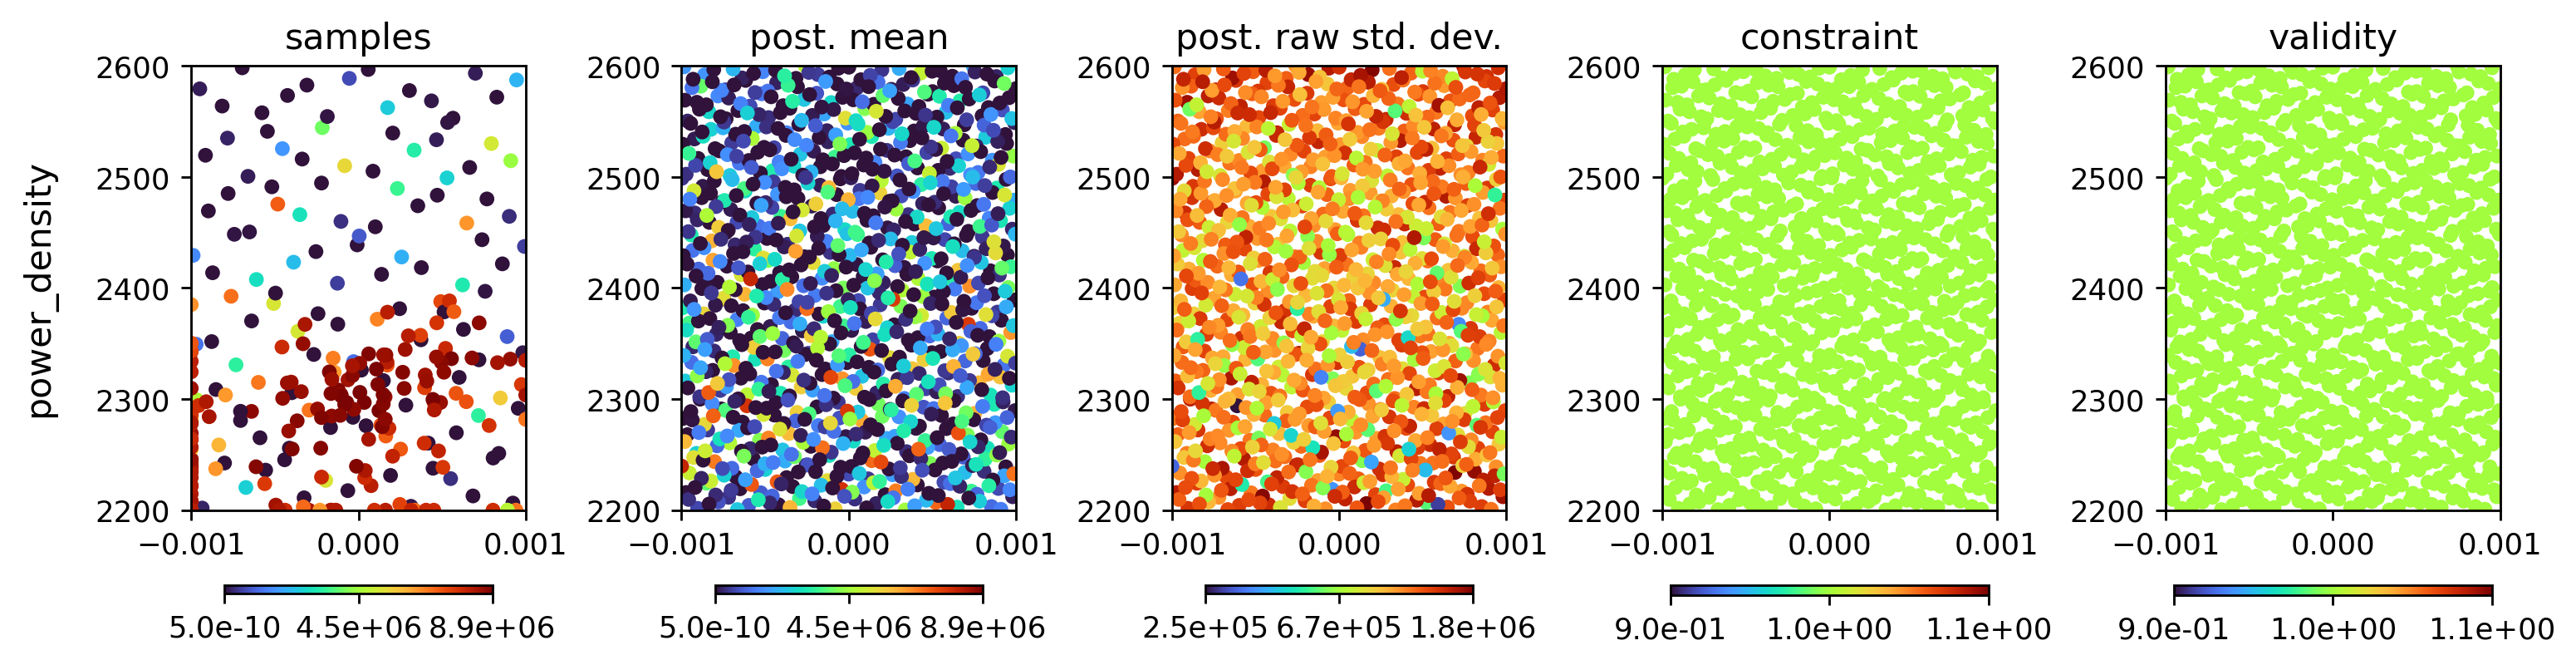

In [50]:
agent.plot_objectives()
print(agent.best)

0.9199000000000003 0.28879903683979175 0.13837613397532195 0.0004961014130629119 0.08825930057281205
0.9311000000000003 0.289226721789902 0.14399535125511204 0.0004003994285340383 0.02320716569707894
0.9986000000000004 0.30402580698801457 0.35128390363080075 0.0066322734833853545 -0.12019900441177686


Text(0.05, -0.05, 'Intensity = 0.9986\nσx = 0.304 mm\nσy = 0.3513 mm\nx_rot = 0 deg\nr_maj = 2400 mm\nmono_angle = 75.69 deg\nslit_cx = 0 mm\nslit_cz = 0 mm\n')

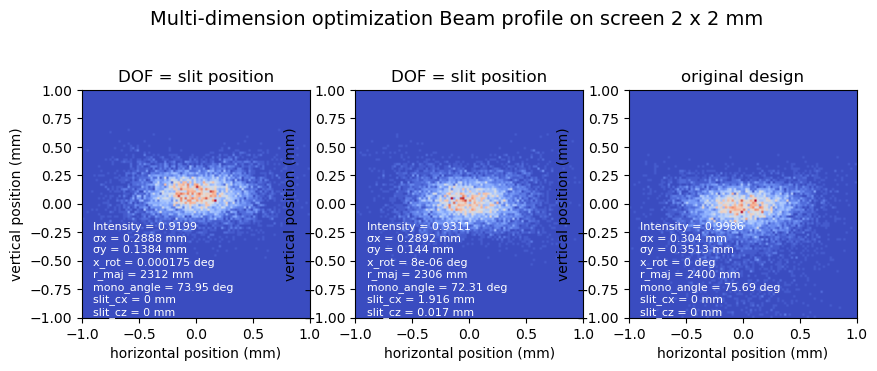

In [55]:
plt.figure(figsize=(10, 4))

# Overall figure title
plt.suptitle('Multi-dimension optimization Beam profile on screen 2 x 2 mm', fontsize=14)

# --- First subplot ---
x_rot =  0.000175                                                                                                                                                                                                                                                                                                  
r_maj =  2312.256592
mono_angle = 73.947098
slit_cx = 0
slit_cz = 0
slit_rx = 0.003324
slit_rz =   0.002348 
X, Y, I = beamline_531(x_rot, r_maj, mono_angle, slit_cx, slit_cz, slit_rx, slit_rz)#, SLIT_RX = entry.slit_rx, SLIT_RZ = entry.slit_rz)
        
X = X * 1e3
Y = Y * 1e3
intensity, sigma_x, sigma_y, x_centroid, y_centroid = beam_rms_size(X, Y, I)
print(intensity, sigma_x, sigma_y, x_centroid, y_centroid)
plt.subplot(1, 3, 1)
hist1, xedges, yedges = np.histogram2d(X, Y, bins=100, range=[[-1, 1], [-1, 1]])
plt.title('DOF = slit position')
plt.imshow(hist1.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
          aspect='equal', origin='lower')
plt.xlabel('horizontal position (mm)')
plt.ylabel('vertical position (mm)')
plt.text(0.05, -0.05,
         f"Intensity = {intensity:.4g}\n"
         f"σx = {sigma_x:.4g} mm\n"
         f"σy = {sigma_y:.4g} mm\n"
         f"x_rot = {x_rot:.4g} deg\n"
         f"r_maj = {r_maj:.4g} mm\n"
         f"mono_angle = {mono_angle:.4g} deg\n"
         f"slit_cx = {slit_cx * 1e3:.4g} mm\n"
         f"slit_cz = {slit_cz * 1e3:.4g} mm\n",
         transform=plt.gca().transAxes,
         fontsize=8, verticalalignment='bottom', color='white')

# --- Second subplot ---
x_rot =  0.000008                                                                                                                                                                                                                                                                                                                     
r_maj =  2306.036621
mono_angle = 72.306389
slit_rx = 0.007507
slit_rz = 0.001741
slit_cx = 0.001916
slit_cz = 0.000017
X, Y, I = beamline_531(x_rot, r_maj, mono_angle, slit_cx, slit_cz, slit_rx, slit_rz)#, SLIT_RX = entry.slit_rx, SLIT_RZ = entry.slit_rz)
        
X = X * 1e3
Y = Y * 1e3
intensity, sigma_x, sigma_y, x_centroid, y_centroid = beam_rms_size(X, Y, I)
print(intensity, sigma_x, sigma_y, x_centroid, y_centroid)
plt.subplot(1, 3, 2)
hist1, xedges, yedges = np.histogram2d(X, Y, bins=100, range=[[-1, 1], [-1, 1]])
plt.title('DOF = slit position')
plt.imshow(hist1.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
          aspect='equal', origin='lower')
plt.xlabel('horizontal position (mm)')
plt.ylabel('vertical position (mm)')
plt.text(0.05, -0.05,
         f"Intensity = {intensity:.4g}\n"
         f"σx = {sigma_x:.4g} mm\n"
         f"σy = {sigma_y:.4g} mm\n"
         f"x_rot = {x_rot:.4g} deg\n"
         f"r_maj = {r_maj:.4g} mm\n"
         f"mono_angle = {mono_angle:.4g} deg\n"
         f"slit_cx = {slit_cx * 1e3:.4g} mm\n"
         f"slit_cz = {slit_cz * 1e3:.4g} mm\n",
         transform=plt.gca().transAxes,
         fontsize=8, verticalalignment='bottom', color='white')

# --- Second subplot ---
x_rot =  0.000000                                                                                                                                                                                                                                                                                                                   
r_maj =  2400
mono_angle = 75.6898061088
slit_rx = 0.01
slit_rz = 0.01
slit_cx = 0.00
slit_cz = 0.00
X, Y, I = beamline_531(x_rot, r_maj, mono_angle, slit_cx, slit_cz, slit_rx, slit_rz)#, SLIT_RX = entry.slit_rx, SLIT_RZ = entry.slit_rz)
        
X = X * 1e3
Y = Y * 1e3
intensity, sigma_x, sigma_y, x_centroid, y_centroid = beam_rms_size(X, Y, I)
print(intensity, sigma_x, sigma_y, x_centroid, y_centroid)
plt.subplot(1, 3, 3)
hist1, xedges, yedges = np.histogram2d(X, Y, bins=100, range=[[-1, 1], [-1, 1]])
plt.title('original design')
plt.imshow(hist1.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
          aspect='equal', origin='lower')
plt.xlabel('horizontal position (mm)')
plt.ylabel('vertical position (mm)')
plt.text(0.05, -0.05,
         f"Intensity = {intensity:.4g}\n"
         f"σx = {sigma_x:.4g} mm\n"
         f"σy = {sigma_y:.4g} mm\n"
         f"x_rot = {x_rot:.4g} deg\n"
         f"r_maj = {r_maj:.4g} mm\n"
         f"mono_angle = {mono_angle:.4g} deg\n"
         f"slit_cx = {slit_cx * 1e3:.4g} mm\n"
         f"slit_cz = {slit_cz * 1e3:.4g} mm\n",
         transform=plt.gca().transAxes,
         fontsize=8, verticalalignment='bottom', color='white')

0.3178000000000001 0.2466125969918571 0.08669454424017752 0.014386298653449165 1.129492395093085
0.9361000000000003 0.28856029185763804 0.14401679947846968 0.0007853093985479532 0.36130135220455833
0.9989000000000003 0.2968392192988747 0.2643184594534825 -0.004658851668415242 0.18600970635389338


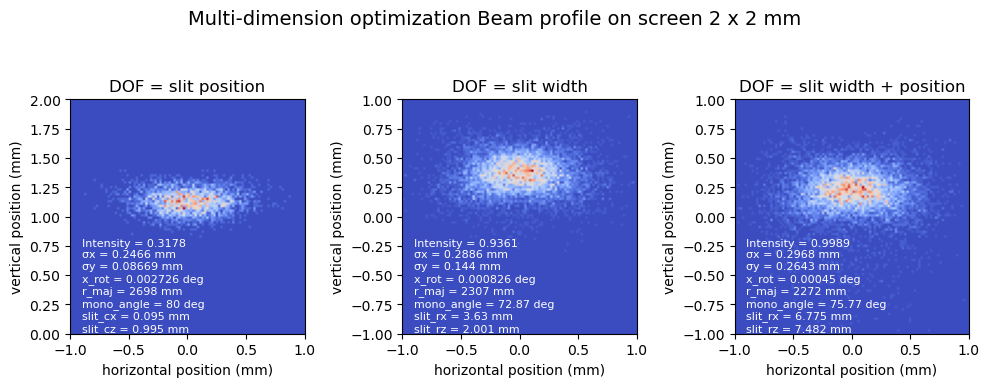

In [56]:
plt.figure(figsize=(10, 4))

# Overall figure title
plt.suptitle('Multi-dimension optimization Beam profile on screen 2 x 2 mm', fontsize=14)

# --- First subplot ---
x_rot =  0.002726                       
r_maj = 2697.888916
mono_angle = 80
slit_cx = 0.000095
slit_cz =  0.000995
X, Y, I = beamline_531(x_rot, r_maj, mono_angle, slit_cx, slit_cz)
X = X * 1e3
Y = Y * 1e3
intensity, sigma_x, sigma_y, x_centroid, y_centroid = beam_rms_size(X, Y, I)
print(intensity, sigma_x, sigma_y, x_centroid, y_centroid)
plt.subplot(1, 3, 1)
hist1, xedges, yedges = np.histogram2d(X, Y, bins=100, range=[[-1, 1], [0, 2]])
plt.title('DOF = slit position')
plt.imshow(hist1.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='equal', origin='lower')
plt.xlabel('horizontal position (mm)')
plt.ylabel('vertical position (mm)')
plt.text(0.05, -0.05,
         f"Intensity = {intensity:.4g}\n"
         f"σx = {sigma_x:.4g} mm\n"
         f"σy = {sigma_y:.4g} mm\n"
         f"x_rot = {x_rot:.4g} deg\n"
         f"r_maj = {r_maj:.4g} mm\n"
         f"mono_angle = {mono_angle:.4g} deg\n"
         f"slit_cx = {slit_cx * 1e3:.4g} mm\n"
         f"slit_cz = {slit_cz * 1e3:.4g} mm\n",
         transform=plt.gca().transAxes,
         fontsize=8, verticalalignment='bottom', color='white')

# --- Second subplot ---
x_rot =  0.000826                               
r_maj = 2306.75415
mono_angle = 72.873253
slit_rx = 0.00363
slit_rz =  0.002001
X, Y, I = beamline_531(x_rot, r_maj, mono_angle, SLIT_RX = slit_rx, SLIT_RZ = slit_rz)
X = X * 1e3
Y = Y * 1e3
intensity, sigma_x, sigma_y, x_centroid, y_centroid = beam_rms_size(X, Y, I)
print(intensity, sigma_x, sigma_y, x_centroid, y_centroid)
plt.subplot(1, 3, 2)
hist1, xedges, yedges = np.histogram2d(X, Y, bins=100, range=[[-1, 1], [-1, 1]])
plt.title('DOF = slit width')
plt.imshow(hist1.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='equal', origin='lower')
plt.xlabel('horizontal position (mm)')
plt.ylabel('vertical position (mm)')
plt.text(0.05, -0.05,
         f"Intensity = {intensity:.4g}\n"
         f"σx = {sigma_x:.4g} mm\n"
         f"σy = {sigma_y:.4g} mm\n"
         f"x_rot = {x_rot:.4g} deg\n"
         f"r_maj = {r_maj:.4g} mm\n"
         f"mono_angle = {mono_angle:.4g} deg\n"
         f"slit_rx = {slit_rx * 1e3:.4g} mm\n"
         f"slit_rz = {slit_rz * 1e3:.4g} mm\n",
         transform=plt.gca().transAxes,
         fontsize=8, verticalalignment='bottom', color='white')
# --- Third subplot ---
x_rot =  0.00045                                                   
r_maj = 2271.625488
mono_angle = 75.766228
slit_rx = 0.006775
slit_rz =  0.007482
slit_cx = -0.000269
slit_cz = -0.000591   
X, Y, I = beamline_531(x_rot, r_maj, mono_angle, slit_cx, slit_cz, SLIT_RX = slit_rx, SLIT_RZ = slit_rz)
X = X * 1e3
Y = Y * 1e3
intensity, sigma_x, sigma_y, x_centroid, y_centroid = beam_rms_size(X, Y, I)
print(intensity, sigma_x, sigma_y, x_centroid, y_centroid)
plt.subplot(1, 3, 3)
hist1, xedges, yedges = np.histogram2d(X, Y, bins=100, range=[[-1, 1], [-1, 1]])
plt.title('DOF = slit width + position')
plt.imshow(hist1.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='equal', origin='lower')
plt.xlabel('horizontal position (mm)')
plt.ylabel('vertical position (mm)')
plt.text(0.05, -0.05,
         f"Intensity = {intensity:.4g}\n"
         f"σx = {sigma_x:.4g} mm\n"
         f"σy = {sigma_y:.4g} mm\n"
         f"x_rot = {x_rot:.4g} deg\n"
         f"r_maj = {r_maj:.4g} mm\n"
         f"mono_angle = {mono_angle:.4g} deg\n"
         f"slit_rx = {slit_rx * 1e3:.4g} mm\n"
         f"slit_rz = {slit_rz * 1e3:.4g} mm\n",
         transform=plt.gca().transAxes,
         fontsize=8, verticalalignment='bottom', color='white')
plt.tight_layout()

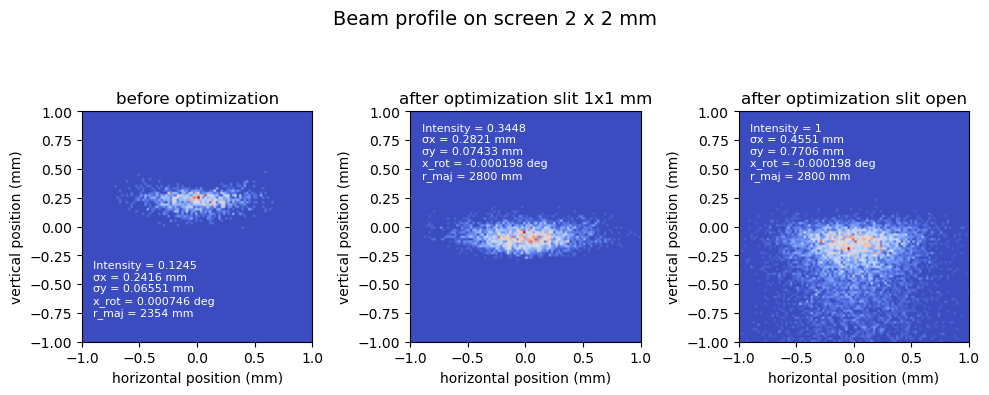

In [209]:
plt.figure(figsize=(10, 4))

# Overall figure title
plt.suptitle('Beam profile on screen 2 x 2 mm', fontsize=14)

# --- First subplot ---
x_rot = 0.000746
r_maj = 2354.303694
X, Y, I = beamline_531(x_rot, r_maj)
X = X * 1e3
Y = Y * 1e3
intensity, sigma_x, sigma_y, x_centroid, y_centroid = beam_rms_size(X, Y, I)
plt.subplot(1, 3, 1)
hist1, xedges, yedges = np.histogram2d(X, Y, bins=100, range=[[-1, 1], [-1, 1]])
plt.title('before optimization')
plt.imshow(hist1.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='equal', origin='lower')
plt.xlabel('horizontal position (mm)')
plt.ylabel('vertical position (mm)')
plt.text(0.05, 0.05,
         f"Intensity = {intensity:.4g}\n"
         f"σx = {sigma_x:.4g} mm\n"
         f"σy = {sigma_y:.4g} mm\n"
         f"x_rot = {x_rot:.4g} deg\n"
         f"r_maj = {r_maj:.4g} mm\n",
         transform=plt.gca().transAxes,
         fontsize=8, verticalalignment='bottom', color='white')

# --- Second subplot ---
x_rot = -0.000198
r_maj = 2800.0
X, Y, I = beamline_531(x_rot, r_maj)
X = X * 1e3
Y = Y * 1e3
intensity, sigma_x, sigma_y, x_centroid, y_centroid = beam_rms_size(X, Y, I)
plt.subplot(1, 3, 2)
hist1, xedges, yedges = np.histogram2d(X, Y, bins=100, range=[[-1, 1], [-1, 1]])
plt.title('after optimization slit 1x1 mm')
plt.imshow(hist1.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='equal', origin='lower')
plt.xlabel('horizontal position (mm)')
plt.ylabel('vertical position (mm)')
plt.text(0.05, 0.95,
         f"Intensity = {intensity:.4g}\n"
         f"σx = {sigma_x:.4g} mm\n"
         f"σy = {sigma_y:.4g} mm\n"
         f"x_rot = {x_rot:.4g} deg\n"
         f"r_maj = {r_maj:.4g} mm\n",
         transform=plt.gca().transAxes,
         fontsize=8, verticalalignment='top', color='white')

# --- Third subplot ---
x_rot = -0.000198
r_maj = 2800.0
X, Y, I = beamline_531(x_rot, r_maj, SLIT_RX =  1, SLIT_RZ = 1)
X = X * 1e3
Y = Y * 1e3
intensity, sigma_x, sigma_y, x_centroid, y_centroid = beam_rms_size(X, Y, I)
plt.subplot(1, 3, 3)
hist1, xedges, yedges = np.histogram2d(X, Y, bins=100, range=[[-1, 1], [-1, 1]])
plt.title('after optimization slit open')
plt.imshow(hist1.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           aspect='equal', origin='lower')
plt.xlabel('horizontal position (mm)')
plt.ylabel('vertical position (mm)')
plt.text(0.05, 0.95,  # bottom left
         f"Intensity = {intensity:.4g}\n"
         f"σx = {sigma_x:.4g} mm\n"
         f"σy = {sigma_y:.4g} mm\n"
         f"x_rot = {x_rot:.4g} deg\n"
         f"r_maj = {r_maj:.4g} mm",
         transform=plt.gca().transAxes,
         fontsize=8, verticalalignment='top', color='white')

# Adjust layout so title fits
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
plt.show()